Successfully loaded 803_2_PD_REST.mat | Shape: (67, 208501)
Successfully loaded 818_2_PD_REST.mat | Shape: (67, 153001)


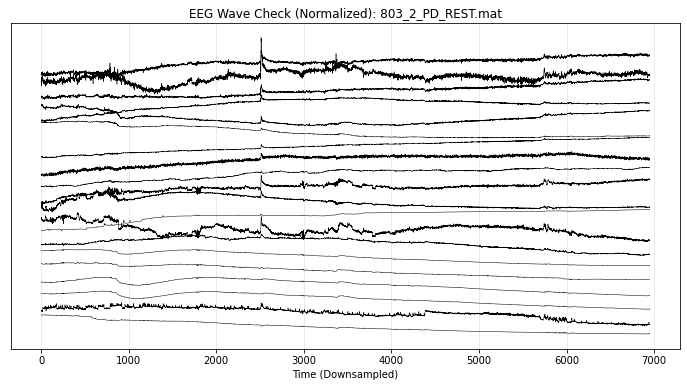

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import mat73
import scipy.io
from scipy.signal import butter, filtfilt, iirnotch, welch
from sklearn.decomposition import FastICA

def extract_eeg_info(eeg_struct):
    """Extract EEG data fields into a dictionary."""
    return {
        'subject': eeg_struct.get('subject', 'Unknown'),
        'group': eeg_struct.get('group', 'Unknown'),
        'condition': eeg_struct.get('condition', 'Unknown'),
        'nbchan': int(eeg_struct.get('nbchan', 0)),
        'trials': int(eeg_struct.get('trials', 0)),
        'pnts': int(eeg_struct.get('pnts', 0)),
        'srate': float(eeg_struct.get('srate', 0)),
        'data': eeg_struct.get('data'),
        'data_shape': eeg_struct['data'].shape if 'data' in eeg_struct else (0,0),
        'times': eeg_struct.get('times')
    }

def analyze_eeg_data(file_path):
    try:
        try:
            data = mat73.loadmat(file_path)
        except:
            data = scipy.io.loadmat(file_path)
            
        if 'EEG' in data:
            eeg_content = data['EEG']
            if hasattr(eeg_content, 'dtype') and eeg_content.shape == (1, 1):
                eeg_content = eeg_content[0, 0]
                eeg_content = {name: eeg_content[name] for name in eeg_content.dtype.names}
            return extract_eeg_info(eeg_content)
    except Exception as e:
        print(f"Failed to load {os.path.basename(file_path)}: {e}")
    return None

def plot_eeg_signal(eeg_info, subject_name, num_channels=20):
    """Plot channels with auto-scaling to prevent flat-line effect."""
    data = eeg_info['data']
    if data is None: return

    if len(data.shape) == 3: data = data[0, :, :]
        
    # Downsample for speed
    step = 30
    plot_data = data[:num_channels, ::step]
    
    plt.figure(figsize=(12, 6))
    
    # Auto-scale: Normalize each channel so waves are visible
    for i in range(min(num_channels, plot_data.shape[0])):
        ch_data = plot_data[i]
        # Normalize: (data - mean) / std dev makes waves visible
        std_val = np.nanstd(ch_data)
        normalized = (ch_data - np.nanmean(ch_data)) / (std_val if std_val > 0 else 1)
        plt.plot(normalized + (i * 2.5), color='black', linewidth=0.5)
        
    plt.title(f"EEG Wave Check (Normalized): {subject_name}")
    plt.xlabel("Time (Downsampled)")
    plt.yticks([])
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

def main():
    current_dir = os.path.join(os.getcwd(), 'PD_REST')
    mat_files = [f for f in os.listdir(current_dir) if f.endswith('.mat') and not f.endswith('1.mat')]
    
    # Pick 4 random subjects
    selected_files = ['803_2_PD_REST.mat', '818_2_PD_REST.mat']
    
    plot_data = None
    plot_subject = None

    for file in selected_files:
        eeg_info = analyze_eeg_data(os.path.join(current_dir, file))
        
        # FIX: Check for NoneType before accessing
        if eeg_info and eeg_info['data'] is not None and eeg_info['data'].size > 0:
            print(f"Successfully loaded {file} | Shape: {eeg_info['data_shape']}")
            if plot_data is None:
                plot_data, plot_subject = eeg_info, file
        else:
            print(f"Skipping {file}: No valid data found.")

    if plot_data:
        plot_eeg_signal(plot_data, plot_subject)

if __name__ == "__main__":
    main()

In [3]:
def extract_channel_labels(info):

    labels = None

    if 'chanlocs' in info:

        chanlocs = info['chanlocs']

        try:
            # mat73 format
            labels = [c['labels'] for c in chanlocs]

        except:
            try:
                # scipy format
                labels = [c[0] for c in chanlocs]
            except:
                print("Could not parse channel labels.")

    if labels:
        print("\nFirst 10 channel labels:")
        print(labels[:10])

    return labels

In [4]:
from scipy.signal import welch

def plot_psd_all_channels(self, raw_data, subject):

    data = self.preprocess(raw_data)

    plt.figure(figsize=(10,6))

    for ch in range(min(10, data.shape[0])):

        f, pxx = welch(
            data[ch],
            fs=self.srate,
            nperseg=2048
        )

        plt.semilogy(
            f,
            pxx,
            alpha=0.5
        )

    plt.title(f"PSD (First 10 Channels) - {subject}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.xlim(0, 50)

    plt.grid(True)

    plt.show()

In [5]:
def plot_psd_with_bands(self, raw_data, subject):

    data = self.preprocess(raw_data)

    f, pxx = welch(
        data[0],  # one channel (you can change later)
        fs=self.srate,
        nperseg=2048
    )

    plt.figure(figsize=(10,6))

    plt.semilogy(f, pxx, label="PSD")

    # Highlight EEG bands
    plt.axvspan(0.5, 4, alpha=0.2, label='Delta')
    plt.axvspan(4, 8, alpha=0.2, label='Theta')
    plt.axvspan(8, 13, alpha=0.2, label='Alpha')
    plt.axvspan(13, 30, alpha=0.2, label='Beta')

    plt.title(f"EEG Frequency Bands - {subject}")

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")

    plt.xlim(0, 40)

    plt.legend()

    plt.grid(True)

    plt.show()

In [6]:
def compute_band_power(self, raw_data):

    data = self.preprocess(raw_data)

    bands = {
        'Delta': (0.5, 4),
        'Theta': (4, 8),
        'Alpha': (8, 13),
        'Beta': (13, 30)
    }

    results = {}

    for name, (low, high) in bands.items():

        band_power = []

        for ch in range(data.shape[0]):

            filtered = self.filter_signal(
                data[ch],
                low,
                high
            )

            power = np.mean(filtered**2)

            band_power.append(power)

        results[name] = np.mean(band_power)

    print("\nBand Power Summary:")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return results


Processing: 803_2_PD_REST.mat

Running ICA...


c:\Users\User\Anaconda3\lib\site-packages\sklearn\decomposition\_fastica.py:119: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  ConvergenceWarning,


ICA Sources shape: (50000, 67)


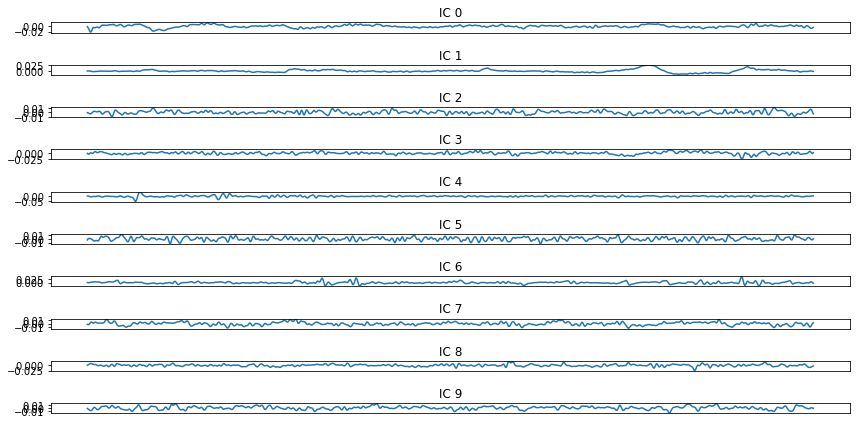

Shape after preprocess: (67, 50000)


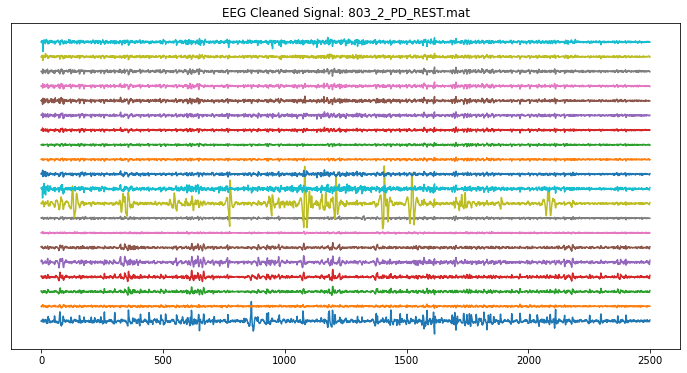


Running ICA...


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import mat73
import scipy.io

from scipy.signal import butter, filtfilt, iirnotch, welch
from sklearn.decomposition import FastICA
import mne


class PDBrainProcessor:

    def __init__(self, srate):

        self.srate = float(np.squeeze(srate))

        self.bands = {
            'Delta': (0.5, 4),
            'Theta': (4, 8),
            'Alpha': (8, 13),
            'Beta (Motor)': (13, 30),
            'Tremor': (3, 6)
        }

    # --------------------------------------------------
    # ORIENTATION FIX
    # --------------------------------------------------

    def ensure_channel_first(self, data):
        if data.shape[0] > data.shape[1]:
            data = data.T
        return data

    # --------------------------------------------------
    # FILTERING
    # --------------------------------------------------

    def apply_bandpass(self, data, low=1.0, high=40.0):
        nyq = 0.5 * self.srate
        b, a = butter(4, [low / nyq, high / nyq], btype='band')
        return filtfilt(b, a, data, axis=-1)

    def apply_notch(self, data, freq=50.0):
        nyq = 0.5 * self.srate
        b, a = iirnotch(freq / nyq, 35)
        return filtfilt(b, a, data, axis=-1)

    def apply_avg_ref(self, data):
        return data - np.mean(data, axis=0, keepdims=True)

    # --------------------------------------------------
    # ICA
    # --------------------------------------------------

    def apply_ica(self, data):
        print("\nRunning ICA...")
        data_t = data.T

        n_channels = data.shape[0]

        self.ica = FastICA(
           n_components=n_channels,
            max_iter=5000,
            tol=1e-2,   # <- slightly looser tolerance helps convergence
            whiten='unit-variance',
            fun='logcosh',
            random_state=42
        )

        sources = self.ica.fit_transform(data_t)

        print("ICA Sources shape:", sources.shape)
        return sources

    # --------------------------------------------------
    # TOPOMAPS (IMPORTANT PART)
    # --------------------------------------------------

    def plot_ica_topomaps(self, labels, n_components=10):

        print("\nPlotting ICA topomaps...")

        n_channels = self.ica.mixing_.shape[0]

        info = mne.create_info(ch_names=labels, sfreq=self.srate, ch_types="eeg")
        montage = mne.channels.make_standard_montage("standard_1020")
        info.set_montage(montage, on_missing='ignore')
        fig, axes = plt.subplots(1, min(n_components, n_channels), figsize=(15, 3))

        for i in range(min(n_components, n_channels)):
            mne.viz.plot_topomap(self.ica.mixing_[:, i], info, axes=axes[i], show=False, extrapolate='head')
            axes[i].set_title(f"IC {i}")

        plt.tight_layout()
        plt.show()

    def get_labels(self, raw_data):
        n_channels = raw_data.shape[0]
        return [f"EEG{i}" for i in range(n_channels)]
    # --------------------------------------------------
    # ICA CLEANING
    # --------------------------------------------------

    def remove_ica_components(self, sources, bad_components=[]):
        sources_clean = sources.copy()
        sources_clean[:, bad_components] = 0
        reconstructed = self.ica.inverse_transform(sources_clean)
        return reconstructed.T

    # --------------------------------------------------
    # PIPELINE
    # --------------------------------------------------

    def preprocess(self, raw_data, bad_ica_components=None):

        data = np.squeeze(raw_data)
        data = data[:, :50000]  # or even 20000 for testing
        data = self.ensure_channel_first(data)
        labels = self.get_labels(data)
        data = self.apply_bandpass(data)
        data = self.apply_notch(data)
        data = self.apply_avg_ref(data)
        sources = self.apply_ica(data)
        # ICA components plot (time series)
        self.plot_ica_components(sources)
        if bad_ica_components is None:
            bad_ica_components = []
        data = self.remove_ica_components(sources, bad_ica_components)
        print("Shape after preprocess:", data.shape)

        return data
    
    # --------------------------------------------------
    # EXTRACT CHANNEL LABELS FROM EEGLAB chanlocs
    # --------------------------------------------------

    def extract_channel_labels(chanlocs):
        labels = []
        # chanlocs usually has shape (1, N)
        for ch in chanlocs[0]:
            try:
                # First field contains the label, e.g. array(['Fp1'], dtype='<U3')
                label = ch[0]
                # Convert nested numpy arrays to plain Python string
                while isinstance(label, np.ndarray):
                    if label.size == 0:
                        label = "Unknown"
                        break
                    label = label.flat[0]

                labels.append(str(label))

            except Exception:
                labels.append("Unknown")

        return labels

    # --------------------------------------------------
    # ICA TIME SERIES
    # --------------------------------------------------

    def plot_ica_components(self, sources, num_components=10):
        plt.figure(figsize=(12, 6))
        for i in range(min(num_components, sources.shape[1])):
            plt.subplot(num_components, 1, i + 1)
            plt.plot(sources[:2000, i])
            plt.title(f"IC {i}")
            plt.xticks([])

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # EEG PLOT
    # --------------------------------------------------

    def plot_eeg_signal_filtered(self, raw_data, subject_name, bad_ica_components=None):
        data = self.preprocess(raw_data, bad_ica_components)
        step = 20
        plot_data = data[:20, ::step]
        plt.figure(figsize=(12, 6))
        spacing = 200
        for i in range(plot_data.shape[0]):
            plt.plot(plot_data[i] + i * spacing)

        plt.title(f"EEG Cleaned Signal: {subject_name}")
        plt.yticks([])
        plt.show()

    # --------------------------------------------------
    # PSD
    # --------------------------------------------------

    def plot_psd(self, raw_data, bad_ica_components=None):
        data = self.preprocess(raw_data, bad_ica_components)
        sig = data[0]
        f, pxx = welch(sig, fs=self.srate, nperseg=2048)
        plt.figure()
        plt.semilogy(f, pxx)
        plt.title("PSD")
        plt.xlim(0, 50)
        plt.show()


# --------------------------------------------------
# LOAD EEG
# --------------------------------------------------

def load_eeg(path):
    try:
        data = mat73.loadmat(path)
    except:
        data = scipy.io.loadmat(path)

    eeg = data.get('EEG', {})
    if hasattr(eeg, 'dtype'):
        eeg = {n: eeg[0, 0][n] for n in eeg.dtype.names}

    return eeg


# --------------------------------------------------
# MAIN
# --------------------------------------------------

def main():

    path = os.path.join(os.getcwd(), 'PD_REST')
    selected_files = ['803_2_PD_REST.mat']
    # , '818_2_PD_REST.mat'
    bad_components = [0]
    for file in selected_files:
        info = load_eeg(os.path.join(path, file))
        if info.get('data') is not None and info.get('srate') is not None:
            print("\nProcessing:", file)
            proc = PDBrainProcessor(info['srate'])
            proc.plot_eeg_signal_filtered(info['data'], file, bad_ica_components=bad_components)
            proc.plot_psd(info['data'], bad_ica_components=bad_components)
            labels = extract_channel_labels(info['chanlocs'])
            plot_ica_topomaps_from_processor(proc, labels=labels, n_components=10)
        else:
            print("Missing data:", file)


if __name__ == "__main__":
    main()